In [1]:
%load_ext autoreload
%autoreload 2

Import modules

In [2]:
from ase.io import read
from ase.visualize import view
import numpy as np 
import torch 
import metatensor 
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

from metatensor import Labels, TensorBlock, TensorMap
from mlelec.data.dataset import QMDataset

from mlelec.utils.plot_utils import print_matrix, matrix_norm, block_matrix_norm

from metatensor import load, sort
from mlelec.utils.twocenter_utils import _to_coupled_basis
from mlelec.utils.pbc_utils import matrix_to_blocks, kmatrix_to_blocks, TMap_bloch_sums, precompute_phase

from mlelec.features.acdc import pair_features, single_center_features, twocenter_features_periodic_NH, twocenter_hermitian_features
import rascaline

def get_targets(dataset, device ="cpu", cutoff = None, target='fock', all_pairs= True):
    
    blocks = matrix_to_blocks(dataset, device = device, cutoff = cutoff, all_pairs = all_pairs, target = target)
    coupled_blocks = _to_coupled_basis(blocks, skip_symmetry = True, device = device, translations = True)

    blocks = blocks.to(arrays='numpy')
    blocks = sort(blocks)
    blocks = blocks.to(arrays='torch')
    
    coupled_blocks = coupled_blocks.to(arrays='numpy')
    coupled_blocks = sort(coupled_blocks)
    coupled_blocks = coupled_blocks.to(arrays='torch')
    
    return blocks, coupled_blocks

/home/pegolo/micromamba/envs/sci/lib/python3.11/site-packages/pyscf/dft/libxc.py:771: UserWarning: Since PySCF-2.3, B3LYP (and B3P86) are changed to the VWN-RPA variant, corresponding to the original definition by Stephens et al. (issue 1480) and the same as the B3LYP functional in Gaussian. To restore the VWN5 definition, you can put the setting "B3LYP_WITH_VWN5 = True" in pyscf_conf.py
  warnings.warn('Since PySCF-2.3, B3LYP (and B3P86) are changed to the VWN-RPA variant, '


In [3]:
device = 'cpu'

In [5]:
rascaline.__version__

'0.1.0.dev532'

In [4]:
orbitals = {
    'sto-3g': {6: [[1,0,0],[2,0,0],[2,1,-1], [2,1,0],[2,1,1]]}, 
    'def2svp': {6: [[1,0,0],[2,0,0],[3,0,0],[2,1,1], [2,1,-1],[2,1,0], [3,1,1], [3,1,-1],[3,1,0], [3,2,-2], [3,2,-1],[3,2,0], [3,2,1],[3,2,2]]},
    'gthszvmolopt': {6: [[2, 0, 0], [2, 1, -1], [2, 1, 0], [2, 1, 1]]}
}

In [5]:
# workdir = './'
# root = f'{workdir}/examples/data/periodic'
# ORBS = 'sto-3g'
# START = 0
# STOP = 1
# frames = read(f'{root}/c2/cp2k/sto-3g/C2_174.extxyz', slice(START, STOP))
# for f in frames: 
#     cell = f.cell.array
#     cell[2] = np.array([0,0,70])
#     f.set_cell(cell)
#     f.pbc = [True, True, False]
#     f.wrap(center=(0.,0.,0.))
#     f.pbc = [True, True, True]

# kmesh = [8,8,1]
# kfock = [np.load(f"{root}/c2/cp2k/sto-3g/881/fock_{i}.npy") for i in range(START, STOP)]
# kover = [np.load(f"{root}/c2/cp2k/sto-3g/881/overlap_{i}.npy") for i in range(START, STOP)]

# dataset = QMDataset(frames = frames, kmesh = kmesh, 
#                                dimension = 2,
#                                fock_kspace = [kfock[ifr][:] for ifr in range(len(frames))], 
#                                overlap_kspace = [kover[ifr][:] for ifr in range(len(frames))],
#                                device = device, orbs = orbitals[ORBS], orbs_name = ORBS)

In [6]:
workdir = './'
root = f'{workdir}/examples/data/periodic'
ORBS = 'sto-3g'
START = 0
STOP = 4
frames = read(f'{root}/deepH_graphene/wrap/wrapped_deepH_graphene.xyz', slice(START, STOP))
# for f in frames:
#     cell = f.cell.array
#     cell[2] = np.array([0,0,70])
#     f.set_cell(cell)
#     f.pbc = [True, True, False]
#     f.wrap(center=(0.,0.,0.))
#     f.pbc = [True, True, True]

kmesh = [1,1,1]
# kfock = [np.load(f"{root}/deepH_graphene/wrap/fock_{i}.npy") for i in range(START, STOP)]
# kover = [np.load(f"{root}/deepH_graphene/wrap/overlap_{i}.npy") for i in range(START, STOP)]
rfock = [np.load(f"{root}/deepH_graphene/wrap/realfock_{i}.npy", allow_pickle = True).item() for i in range(START, STOP)]
rover = [np.load(f"{root}/deepH_graphene/wrap/realoverlap_{i}.npy", allow_pickle = True).item() for i in range(START, STOP)]

dataset = QMDataset(frames = frames, 
                               kmesh = kmesh, 
                               dimension = 2,
                               fock_realspace = rfock, 
                               overlap_realspace = rover, 
                               # fock_kspace = kfock, 
                               # overlap_kspace = kover, 
                               device = device, 
                               orbs = orbitals[ORBS], 
                               orbs_name = 'sto-3g')

# Targets

In [7]:
cutoff = 6
target_blocks, target_coupled_blocks = get_targets(dataset, cutoff = cutoff, device = device, all_pairs = False)

ValueError: not enough values to unpack (expected 3, got 1)

In [8]:
from mlelec.utils.pbc_utils import blocks_to_matrix
rHT = blocks_to_matrix(target_blocks, dataset)
rHk = dataset.bloch_sum(rHT)
print(torch.norm(rHk[0]-dataset.fock_kspace[0]))

tensor(0.0001)


In [9]:
workdir = './'
root = f'{workdir}/examples/data/periodic'
ORBS = 'sto-3g'
START = 0
STOP = 4
frames = read(f'{root}/deepH_graphene/wrap/wrapped_deepH_graphene.xyz', slice(START, STOP))

kmesh = [1,1,1]

dataset_fake = QMDataset(frames = frames, 
                               kmesh = kmesh, 
                               dimension = 2,
                               fock_kspace = rHk, 
                               # overlap_kspace = kover, 
                               device = device, 
                               orbs = orbitals[ORBS], 
                               orbs_name = 'sto-3g')

/home/pegolo/Software/mlelec/src/mlelec/data/dataset.py:872: UserWarning: Overlap matrices not provided
  warnings.warn("Overlap matrices not provided")


In [15]:
k_target_blocks = kmatrix_to_blocks(dataset, cutoff = cutoff, all_pairs = False)

In [11]:
phase, indices = precompute_phase(target_blocks, dataset, cutoff = cutoff)
pred_kspace = TMap_bloch_sums(target_blocks, phase, indices)

In [12]:
metatensor.equal_metadata(k_target_blocks, pred_kspace)

True

# Features

In [8]:
import rascaline
max_radial  = 8
max_angular = 5
atomic_gaussian_width = 0.3
spline_basis = False
##---splined basis 
if spline_basis :
    spliner = rascaline.utils.SoapSpliner(
        cutoff=cutoff,
        max_radial=max_radial,
        max_angular=max_angular,
        basis=rascaline.utils.SphericalBesselBasis(
            cutoff=cutoff, max_radial=max_radial, max_angular=max_angular
        ),
        density=rascaline.utils.GaussianDensity(atomic_gaussian_width=atomic_gaussian_width),
        accuracy=1e-5,
    )
    splined_basis = spliner.compute()
##-------
hypers_pair = {'cutoff': cutoff,
               'max_radial': max_radial,
               'max_angular': max_angular,
               'atomic_gaussian_width': atomic_gaussian_width,
               'center_atom_weight': 1,
               "radial_basis": splined_basis if spline_basis else {"Gto": {}},
               # "radial_basis": splined_basis,
               "cutoff_function": {"ShiftedCosine": {"width": 0.1}}}

hypers_atom = {'cutoff': 4,
               'max_radial': max_radial,
               'max_angular': max_angular,
               'atomic_gaussian_width': 0.3,
               'center_atom_weight': 1,
               "radial_basis": {"Gto": {}},
               "cutoff_function": {"ShiftedCosine": {"width": 0.1}}}

return_rho0ij = False
both_centers = False
all_pairs = False
LCUT = 3

def compute_features(dataset):

    rhoij = pair_features(dataset.structures, hypers_atom, hypers_pair, order_nu = 1, all_pairs = all_pairs, both_centers = both_centers, mic = False,
                          kmesh = dataset.kmesh, device = device, lcut = LCUT, return_rho0ij = return_rho0ij, counter = None, 
                          T_dict = None)  
    
    if both_centers and not return_rho0ij:
        NU = 3
    else:
        NU = 2
    rhonui = single_center_features(dataset.structures, hypers_atom, order_nu = NU, lcut = LCUT, device = device,
                                    feature_names = rhoij.property_names)
    
    hfeat = twocenter_features_periodic_NH(single_center = rhonui, pair = rhoij, all_pairs = all_pairs)

    return hfeat

In [11]:
%%timeit
hfeat = compute_features(dataset)

40.1 s ± 304 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [82]:
pc = pred.copy()
newb = []
for _,b in pred.items():
    newb.append(TensorBlock(samples=b.samples, properties=b.properties, components=b.components, values=b.values.detach()))
newmap = TensorMap(pred.keys, newb)

In [83]:
metatensor.save('aaa', newmap)

# Train

## Ridge regression

In [25]:
from mlelec.models.linear import LinearModelPeriodic
device='cpu'

In [26]:
def train_ridge(model, target_blocks, set_bias=False, alphas = None, kernel_ridge = False, alpha = None):
    block_losses = {}
    loss = 0
    pred, ridges = model.fit_ridge_analytical(return_matrix = False, set_bias = set_bias, kernel_ridge = kernel_ridge, alphas = alphas, alpha = alpha)

    for (key, block) in pred.items():
        block_loss=torch.norm(block.values - target_blocks[key].values)**2
        loss += block_loss
        
        block_losses[tuple(key.values)] = block_loss

    # print(np.sum(list(block_losses.values())))
    return loss, pred, ridges, block_losses#, kernels 

In [27]:
model_ridge = LinearModelPeriodic(twocfeat = hfeat, 
                                  target_blocks = target_coupled_blocks,
                                  frames = dataset.structures, orbitals = dataset.basis, 
                                  device = device)

model_ridge = model_ridge.double()
loss_ridge_bias, pred_ridge_bias, ridges_bias, loss_blocks = train_ridge(model_ridge, 
                                                                         target_coupled_blocks,
                                                                         set_bias = True,
                                                                         kernel_ridge = False,
                                                                         alphas = np.logspace(-10, -2, 100),
                                                                         # alphas = np.logspace(-30, -6, 100),
                                                                         # alpha = 1e-4
                                                                        )
print(loss_ridge_bias)

tensor(0.0016)


Compute the feature covariance matrix and diagonalize it. Project the weights onto the covariance eigenstates at each training iteration (TODO)

## Torch

In [18]:
from mlelec.metrics import L2_loss, L2_kspace_loss

In [19]:
from mlelec.models.linear import LinearModelPeriodic

In [101]:
from mlelec.utils.pbc_utils import blocks_to_matrix
from mlelec.utils.symmetry import ClebschGordanReal
CG = ClebschGordanReal(lmax = 3, device = device)

In [118]:
print(y2.swapaxes(1,2).shape) # @ 
a = y2.swapaxes(1,2)
print(((y1.swapaxes(1,2)@cg.reshape(3,35)).reshape(10,11,5,7)).swapaxes(2,0).shape)

torch.Size([10, 11, 5])
torch.Size([5, 11, 10, 7])


In [252]:
s = 10000
m = 3
n = 5
p = 15000
M = 7
y1 = torch.randn(s,m,p)
y2 = torch.randn(s,n,p)
cg = torch.randn(m,n,M)

In [253]:
%%timeit
s, m, p = y1.shape
n, M = cg.shape[1:]
res = (y1.swapaxes(1,2).reshape(s*p, 1, m) @ (y2.swapaxes(1,2).reshape(s*p, n) @ cg).swapaxes(1,0)).reshape(s,p,M).swapaxes(1,2)
# res = torch.matmul(y1.swapaxes(1,2).reshape(s*p,1,m), torch.matmul(y2.swapaxes(1,2).reshape(s*p, n), cg).swapaxes(1,0)).reshape(s,p,M).swapaxes(1,2)

5.58 s ± 67.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [254]:
%%timeit
Y = torch.einsum('smp,snp,mnM->sMp', y1, y2, cg)

KeyboardInterrupt: 

In [168]:
%%timeit

s, m, p = y1.shape
m, n, M = cg.shape
y1_reshaped = y1.swapaxes(1, 2).reshape(s*p, m)
cg_reshaped = cg.reshape(m, n*M)
result_reshaped = torch.matmul(y1_reshaped, cg_reshaped) # s*p,n,M .reshape(s,p,n,M)
                                                         # snp->s|p|n->s*p|n
# s*p, m -- s*p, n, m,n,M
esum = torch.einsum('spnM,snp->sMp', result_reshaped, y2)

50.4 ms ± 442 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [21]:
seed = 10
torch.manual_seed(seed)
np.random.seed(seed)

model = LinearModelPeriodic(twocfeat = hfeat, 
                            target_blocks = target_coupled_blocks,
                            frames = dataset.structures, orbitals = dataset.basis, 
                            device = device,
                            bias = True,
                            nhidden = 512, 
                            nlayers = 1,
                            train_kspace = False,
                            activation = 'SiLU',
                            apply_norm = True
                           )

model = model.double()
# for p, (_, b) in zip(model.parameters(), target_coupled_blocks.items()):
#     p.data = torch.ones_like(p.data)

losses = {}
para = {}
grad = {}
learning_rates = {}
last_layer_kernel = {}
nepoch = 10000

# optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.6, patience=50, verbose=True)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[200, 400, 600, 800], gamma=1e-1)
optimizers = []
schedulers = []
for i, key in enumerate(model.model):
    # optimizers.append(torch.optim.Adam(model.model[key].parameters(), lr = 1e-1)) #, betas = (0.8, 0.9)))
    optimizers.append(torch.optim.AdamW(model.model[key].parameters(), lr = 1e-3, betas = (0.8, 0.9)))
    schedulers.append(torch.optim.lr_scheduler.ReduceLROnPlateau(optimizers[-1], factor = 0.8, patience = 30, verbose=True))

In [23]:
from mlelec.utils.twocenter_utils import _to_uncoupled_basis, map_targetkeys_to_featkeys
from mlelec.utils.pbc_utils import precompute_phase, TMap_bloch_sums

phase, indices = precompute_phase(target_blocks, dataset, cutoff = cutoff)

loss_real = []
loss_k = []

new_sched = True
for epoch in range(nepoch):

    model.train(True)

    for ik, key in enumerate(model.model):
        optimizers[ik].zero_grad()
    
    pred = model()
    unc_pred = _to_uncoupled_basis(pred, cg = CG)
    pred_kspace = TMap_bloch_sums(unc_pred, phase, indices)
    
    n_predictions = sum([np.prod(b.values.shape) for _, b in pred.items()])

    if epoch < 1000:

        # Compute the loss for each block
        all_losses, epoch_loss = L2_loss(pred, target_coupled_blocks, loss_per_block = True)

        # Total loss
        epoch_loss = epoch_loss.item()
        
        # Append the values of the loss to a list
        loss_k.append(L2_loss(pred_kspace, k_target_blocks, norm = 2).item())
        loss_real.append(epoch_loss)

        # Loop through submodels and backpropagate
        for ik, (loss, key) in enumerate(zip(all_losses, model.model)):
            loss.backward(retain_graph = False)
            torch.nn.utils.clip_grad_norm_(model.model[key].parameters(), 1)
            optimizers[ik].step()
            schedulers[ik].step(loss)
            
            if key not in losses:
                losses[key] = [loss.item()]
                learning_rates[key] = [schedulers[ik].state_dict()['_last_lr'][0]]
            else:
                losses[key].append(loss.item())
                learning_rates[key].append(schedulers[ik].state_dict()['_last_lr'][0])
                
    else:

        # Compute the loss
        loss = L2_loss(pred_kspace, k_target_blocks, norm = 2)

        # Total loss 
        epoch_loss = loss.item()
        
        # Append the values of the loss to a list
        loss_real.append(L2_loss(pred, target_coupled_blocks).item())
        loss_k.append(epoch_loss)

        loss.backward(retain_graph = True)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)

        for ik, key in enumerate(model.model):
            optimizers[ik].step()
            schedulers[ik].step(epoch_loss/len(model.model))
        
    if epoch % 10 == 0:
        # print(f"Epoch {epoch:>7d}, train loss on all blocks {epoch_loss:>15.10f}, train loss per prediction {np.sqrt(epoch_loss)/n_predictions:>6.5e}")
        print(f"Epoch {epoch:>7d}, train loss real {loss_real[-1]:>15.10f}, train loss k {loss_k[-1]:>15.10f}, train loss per prediction {np.sqrt(epoch_loss)/n_predictions:>6.5e}")

Epoch       0, train loss real 32296.1976998828, train loss k 31295.7856821398, train loss per prediction 6.23998e-04
Epoch      10, train loss real 10598.8907578783, train loss k 10584.1253406722, train loss per prediction 3.57468e-04
Epoch      20, train loss real  217.8874506578, train loss k  215.2436079830, train loss per prediction 5.12535e-05
Epoch      30, train loss real  124.2618168980, train loss k  120.9680902696, train loss per prediction 3.87058e-05
Epoch 00040: reducing learning rate of group 0 to 8.0000e-04.
Epoch      40, train loss real   17.3846045800, train loss k   15.2395836879, train loss per prediction 1.44774e-05
Epoch 00044: reducing learning rate of group 0 to 8.0000e-04.
Epoch      50, train loss real    5.2289995540, train loss k    3.7977244211, train loss per prediction 7.93993e-06
Epoch 00052: reducing learning rate of group 0 to 8.0000e-04.
Epoch 00054: reducing learning rate of group 0 to 8.0000e-04.
Epoch 00055: reducing learning rate of group 0 to 8.

KeyboardInterrupt: 

In [99]:
a,b=[pred.keys[0][l] for l in ["block_type", "species_i"]]

In [51]:
from mlelec.utils.twocenter_utils import _to_uncoupled_basis, map_targetkeys_to_featkeys
from mlelec.utils.pbc_utils import precompute_phase, TMap_bloch_sums
# kpts_ = torch.from_numpy(np.array(kpts_train)).to(device)

phase, indices = precompute_phase(target_blocks, dataset, cutoff = cutoff)

loss_real = []
loss_k = []

new_sched = True
for epoch in range(nepoch):

    model.train(True)

    for ik, key in enumerate(model.model):
        optimizers[ik].zero_grad()
    
    pred = model()
    n_predictions = sum([np.prod(b.values.shape) for _, b in pred.items()])

    if epoch < 0:
        all_losses, epoch_loss = L2_loss(pred, target_coupled_blocks, loss_per_block = True)
        epoch_loss = epoch_loss.item()
        for ik, (loss, key) in enumerate(zip(all_losses, model.model)):
            loss.backward(retain_graph = False)
            torch.nn.utils.clip_grad_norm_(model.model[key].parameters(), 1)
            optimizers[ik].step()
            # schedulers[ik].step()
            schedulers[ik].step(loss)
            
            if key not in losses:
                losses[key] = [loss.item()]
                learning_rates[key] = [schedulers[ik].state_dict()['_last_lr'][0]]
            else:
                losses[key].append(loss.item())
                learning_rates[key].append(schedulers[ik].state_dict()['_last_lr'][0])
            
        unc_pred = _to_uncoupled_basis(pred, cg = CG)
        # pred_kspace = TMap_bloch_sums(unc_pred, phase, where_inv)
        # loss_k.append(L2_loss(pred_kspace, k_target_blocks, norm = 128).item())
        loss_real.append(epoch_loss)
        # for ik, (key, loss) in enumerate(model.model):
        
    else:
        # if new_sched:
        #     pred_before_k = pred.copy()

        #     optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
        #     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor = 0.5, patience = 200, verbose=True)
        #     # for s, o in zip(schedulers, optimizers):
        #     #     s = torch.optim.lr_scheduler.ReduceLROnPlateau(o, factor = 0.5, patience = 100, verbose=True)
        #     new_sched = False

        #     _loss = L2_kspace_loss(pred, 
        #                       target_kspace, 
        #                       dataset, 
        #                       cg = CG, 
        #                       kpts = kpts_,
        #                       norm = 1
        #                       )
        #     print("Initial k-space loss = ", _loss.item())

        unc_pred = _to_uncoupled_basis(pred, cg = CG)
        pred_kspace = TMap_bloch_sums(unc_pred, phase, indices)
        loss = L2_loss(pred_kspace, k_target_blocks, norm = 2)
        loss_real.append(L2_loss(pred, target_coupled_blocks).item())
        # pred_kspace = None # Allow to deallocate
        # loss = L2_kspace_loss(pred, 
        #               target_kspace, 
        #               dataset, 
        #               cg = CG, 
        #               kpts = kpts_,
        #               norm = 1
        #               ) 

        loss.backward(retain_graph = False)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        epoch_loss = loss.item()

        loss_k.append(epoch_loss)
        # for key in model.model:
        #     if key not in losses:
        #         losses[key] = [epoch_loss/len(model.model)]
        #     else:
        #         losses[key].append(epoch_loss/len(model.model))
    
        for ik, key in enumerate(model.model):
            optimizers[ik].step()
            schedulers[ik].step(epoch_loss)
        
        # optimizer.step()
        # scheduler.step(epoch_loss)

    # for i, key in enumerate(model.model):
    #     if key not in para:
    #         para[key] = {}
    #         # grad[key] = []
    #         # optimizers[0].param_groups[0]['lr']
    #     for i, param in enumerate(model.model[key].parameters()):
    #         # grad[key].append(param.grad.norm().item())
    #         if i not in para[key]:
    #             para[key][i] = []
    #         para[key][i].append(torch.clone(param).detach())

    # for k in model.target_blocks.keys:
    #     kl = tuple(k.values)
    #     if kl not in last_layer_kernel:
    #         last_layer_kernel[kl] = []
    #     feat = map_targetkeys_to_featkeys(hfeat, k)
    #     m = model.model[str(kl)].mlp[:-1].forward(feat.values).detach()
    #     # if epoch == 0:
    #     #     print(kl, m.shape)
    #     # m = m.reshape(-1, m.shape[-1])
    #     mTm = torch.einsum('scf,Scf->csS', m, m)
    #     # mTm = torch.einsum('scf,scg->cfg', m, m)
    #     last_layer_kernel[kl].append(mTm)
    
    if epoch % 10 == 0:
        # print(f"Epoch {epoch:>7d}, train loss on all blocks: {epoch_loss:>15.10f}, sqrt(loss)/n_predictions: {np.sqrt(epoch_loss)/n_predictions:>6.5e}")
        print(f"Epoch {epoch:>7d}, train loss real {loss_real[-1]:>15.10f}, train loss k {loss_k[-1]:>15.10f}, train loss per prediction {np.sqrt(epoch_loss)/n_predictions:>6.5e}")

        # for i, key in enumerate(model.model):
        #     if key not in para:
        #         para[key] = []
        #         grad[key] = []
        #         # optimizers[0].param_groups[0]['lr']
        #     for param in model.model[key].parameters():
        #         grad[key].append(param.grad.norm().item())
        #         para[key].append(param.norm().item())

    #     # validate 
    #     valpred = model.predict(hfeat_test, target_test)
    #     if loss_func == 'kspace':
    #         val_loss = L2_kspace_loss(valpred, target_test, dataset)
    #     else:
    #         val_loss = L2_loss(valpred, target_test)
        
    #     print(f"Epoch {epoch} val loss {val_loss}")


Epoch       0, train loss on all blocks: 31295.7856821398, sqrt(loss)/n_predictions: 6.14257e-04


KeyboardInterrupt: 

Text(0, 0.5, 'Loss')

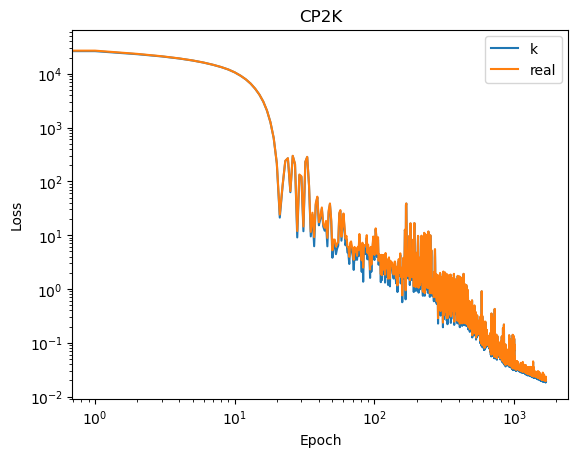

In [24]:
plt.loglog(loss_k, label='k')
plt.loglog(loss_real, label='real')
# plt.axhline(np.mean(np.array(loss_k)/np.array(loss_real)), label = f'avg ratio={np.mean(np.array(loss_k)/np.array(loss_real))}', ls = '--', color = 'k')
# plt.loglog(np.array(loss_k)/np.array(loss_real), label='ratio', color = 'gold')

plt.legend()

plt.title('CP2K')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [38]:
from mlelec.utils.pbc_utils import kblocks_to_matrix
recon_matrix = kblocks_to_matrix(pred_kspace, dataset)
orig_matrix = kblocks_to_matrix(k_target_blocks, dataset)

tensor(30.9684)


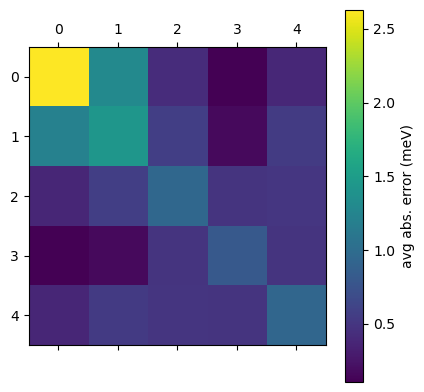

In [91]:
ifr = 0
from ase.units import Hartree

diff = torch.zeros(5,5)
c = 0
std = 0
avg = 0
for i in range(72):
    for j in range(72):
        block1 = recon_matrix[ifr][0][5*i:5*(i+1), 5*j:5*(j+1)]
        block2 = orig_matrix[ifr][0][5*i:5*(i+1), 5*j:5*(j+1)]
        std += np.abs(block2[0,0])**2
        avg += block2[0,0].real
        diff += torch.abs(block1 - block2).detach()
        c += 1
std = std/c
avg = avg/c

plt.matshow(Hartree*diff/c*1000)
cb = plt.colorbar()
cb.set_label('avg abs. error (meV)')
std = np.sqrt(std-avg**2)*Hartree
print(std)

# Bands

In [55]:
def reconstruct(pred, dataset, cutoff):
    from mlelec.utils.pbc_utils import inverse_bloch_sum
    reconstructed_H_ = blocks_to_matrix(pred, dataset)
    reconstructed_H = []
    reconstructed_S = []
    S = [inverse_bloch_sum(dataset, dataset.overlap_kspace[ifr], ifr, cutoff) for ifr in range(len(dataset.structures))]
    for ifr in range(len(reconstructed_H_)):
        reconstructed_H.append({})
        reconstructed_S.append({})
        for T in reconstructed_H_[ifr]:
            if T in S[ifr]:
                reconstructed_S[ifr][T] = S[ifr][T]
                reconstructed_H[ifr][T] = reconstructed_H_[ifr][T].cpu().detach().numpy()
            elif tuple(-np.array(T)) in S[ifr]:
                T = tuple(-np.array(T))
                reconstructed_S[ifr][T] = S[ifr][T]
                reconstructed_H[ifr][T] = reconstructed_H_[ifr][T].cpu().detach().numpy()
            else:
                print(T)
                raise ValueError()
    return reconstructed_H, reconstructed_S

In [56]:
rH_k, rS_k = reconstruct(pred, dataset, cutoff = cutoff)

_, true_target_coupled_blocks = get_targets(dataset, cutoff = 8.35, device = device)
rH_true, rS_true = reconstruct(true_target_coupled_blocks, dataset, cutoff = 8.35)

-0.007484087355638383
-0.007498410787027821


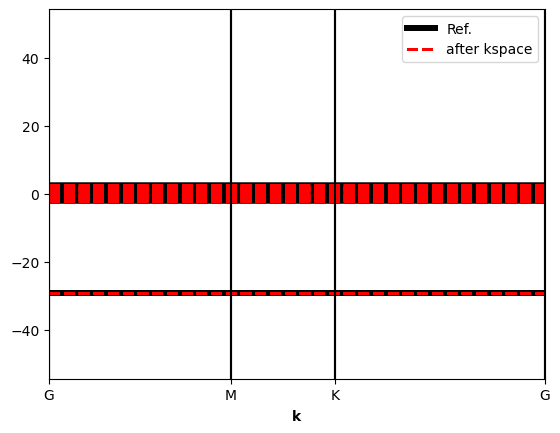

In [57]:
fig, ax = plt.subplots()

special_points = {'G': [0.0, 0.0, 0.0], 'K': [0.3333333333333333, 0.3333333333333333, 0.0], 'M': [0.5, 0.0, 0.0]}

from mlelec.utils.plot_utils import plot_bands_frame_
import matplotlib

ifr = 2
frame = dataset.structures[ifr]
pyscf_cell = dataset.cells[ifr]
kmesh = dataset.kmesh[ifr]
kpath = frame.cell.bandpath('GMKG', 500, special_points = special_points, pbc = [True, True, False])
realfock = np.asarray(list(rH_true[ifr].values())) #np.asarray(list(dataset.fock_realspace[0].values()))
realover = np.asarray(list(rS_true[ifr].values())) #np.asarray(list(dataset.overlap_realspace[0].values()))
R_vec_rel = [list(T) for T in rH_true[ifr]]

handles = []
labels = []

ax, b, handle = plot_bands_frame_(frame, realfock, realover, pyscf_cell, kmesh, special_symm = 'hexagonal', 
                                  factor = 1,
                                  kpath = kpath, ax = ax, color = 'k', R_vec_rel_in = R_vec_rel, lw = 3)
handles.append(tuple(handle))
labels.append('Ref.')

for H, S, c, ls, factor, label in zip([rH_k], [rS_k], ['red'], ['--'], [1], ['after kspace']): #np.sqrt(np.prod(kmesh)/len(H[0]))]):
    # if label == 'only real space':
        # continue
    realfock_cutoff = np.asarray(list(H[ifr].values()))
    realover_cutoff = np.asarray(list(S[ifr].values()))
    R_vec_rel = [list(T) for T in H[ifr]]
    ax, b, handle = plot_bands_frame_(frame, realfock_cutoff, realover_cutoff, pyscf_cell, kmesh, 
                                      factor = factor,
                                      lw = 2,
                                      R_vec_rel_in = R_vec_rel, special_symm = 'hexagonal', kpath = kpath, ax = ax, color = c, ls = ls)
    handles.append(tuple(handle))
    labels.append(label)

ax.legend(handles, labels)
# ax.set_ylim(-35, 43)
# nmax = 50
# for ifr in range(0, nmax):
#     frame = dataset.structures[ifr]
#     pyscf_cell = dataset.cells[ifr]
#     kmesh = dataset.kmesh[ifr]
#     kpath = frame.cell.bandpath('GMKG', 500, special_points = special_points, pbc = [True, True, False])
#     realfock = np.asarray(list(dataset.fock_realspace[ifr].values()))
#     realover = np.asarray(list(dataset.overlap_realspace[ifr].values()))
#     realfock_cutoff = np.asarray(list(reconstructed_H[ifr].values()))
#     realover_cutoff = np.asarray(list(reconstructed_S[ifr].values()))
#     fig, ax = plt.subplots()
#     ax, b = plot_bands_frame_(frame, realfock, realover, pyscf_cell, kmesh = [8,8,1], special_symm = 'hexagonal' , 
#                               kpath = kpath, ax=ax,color = cmap((ifr+1)/nmax))
#     ax, b = plot_bands_frame_(frame, realfock_cutoff, realover_cutoff, pyscf_cell, kmesh = [8,8,1], special_symm = 'hexagonal' , 
#                               kpath = kpath, ax = ax, color = 'k', ls = ':')



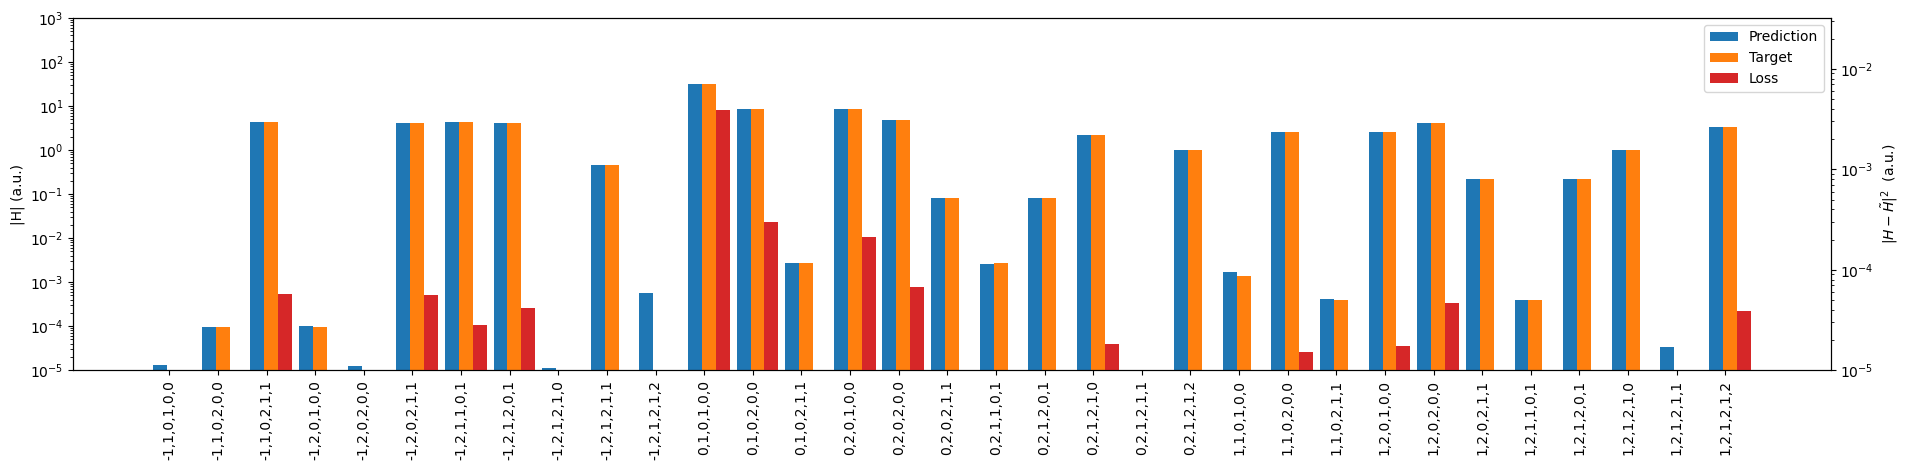

In [835]:
from mlelec.utils.plot_utils import plot_block_errors
fig,ax,ax_loss=plot_block_errors(target_coupled_blocks, pred, plot_loss = True)
ax_loss.set_ylim(1e-5,)
ax.set_ylim(1e-5,)
fig.tight_layout()

# Understanding the factor to equate real and kspace TMap losses

In [672]:
# ni = 2
# li = 1
# nj = 2
# lj = 1

for ni,li,nj,lj in [[1,0,1,0], [1,0,2,0], [1,0,2,1], [2,0,2,0], [2,0,2,1], [2,1,2,1]]:
    
    pred = model()
    pred_unc = _to_uncoupled_basis(pred)
    
    simple_pred = []
    simple_k = []
    for k, b in pred_unc.items():
        if k['n_i'] == ni and k['l_i'] == li and k['n_j'] == nj and k['l_j'] == lj: # and k['block_type'] != 0:
            simple_pred.append(b.copy())
            simple_k.append(k.values.tolist())
    simple_k = Labels(pred_unc.keys.names, np.array(simple_k))
    simple_pred = TensorMap(simple_k, simple_pred)
    
    simple_targ = []
    simple_k = []
    for k, b in target_blocks.items():
        if k['n_i'] == ni and k['l_i'] == li and k['n_j'] == nj and k['l_j'] == lj:
            simple_targ.append(b.copy())
            simple_k.append(k.values.tolist())
    simple_k = Labels(target_blocks.keys.names, np.array(simple_k))
    simple_targ = TensorMap(simple_k, simple_targ)
    
    simple_pred = metatensor.zeros_like(simple_pred)
    simple_targ = metatensor.ones_like(simple_targ)
    
    phase, where_inv = precompute_phase(simple_targ, dataset)
    simple_targ_k = TMap_bloch_sums(simple_targ, phase, where_inv)
    simple_pred_k = TMap_bloch_sums(simple_pred, phase, where_inv)
    
    loss = {}
    loss['k'] = L2_loss(simple_pred_k, simple_targ_k, loss_per_block=False).item()
    loss['r'] = L2_loss(simple_pred, simple_targ, loss_per_block=False).item()
    
    vals = {}
    for tmap, l in zip([simple_pred, simple_pred_k], ['r', 'k']):
        tot = 0
        # print(l)
        for i, (k, b) in enumerate(tmap.items()):
            # print(k.values)
            # print(b.values.shape, np.prod(b.values.shape))
            # tot += b.values.shape[2]*b.values.shape[1]
            tot += np.prod(b.values.shape)
            # print(np.prod(b.values.shape))
            # print()
        # print()
        vals[l] = tot #/(i+1)
    
    # for l in vals:
    #     print(l, loss[l], vals[l])
    
    # print('vals',vals['k']/vals['r'])
    print(f'{ni}{li}-{nj}{lj}   nk={vals["k"]}, nr={vals["r"]}, nk/nr={vals["k"]/vals["r"]}') # Average number of predictions per block {vals["k"]:.3f}, {vals["r"]:.3f} {vals["k"]/vals["r"]}')
    print('loss_k ={:>10.4f}     loss_r ={:>8.4f}     loss_k/loss_r ={:>8.4f}     (loss_k/loss_r)/(nk/nt) ={:>20.15f}'.format(loss['k'], loss['r'], loss['k'] / loss['r'], (loss['k'] / loss['r'])/(vals["k"]/vals["r"])))
    # print('loss {:>10.4f} {:>8.4f} {:>8.4f}'.format(loss['k']/vals['k'], loss['r']/vals['r'], (loss['k']/vals['k'])/(loss['r']/vals['r'])))
    # print('loss {:>10.4f} {:>8.4f} {:>8.4f}'.format(loss['k']/vals['k']**2, loss['r']/vals['r']**2, (loss['k']/vals['k']**2)/(loss['r']/vals['r']**2)))
    # print('loss', loss['k']/vals['k'] / loss['r']*vals['r'])
    
    # for l in vals:
        # print(l, loss[l]/vals[l])
    
    # rat = (loss['k']/loss['r']) / (vals['k']/vals['r'])
    # print(rat)
    
    # print((64/rat)**2)

10-10   nk=128, nr=8, nk/nr=16.0
loss_k =  384.0000     loss_r =  8.0000     loss_k/loss_r = 48.0000     (loss_k/loss_r)/(nk/nt) =   3.000000000000000
10-20   nk=128, nr=8, nk/nr=16.0
loss_k =  384.0000     loss_r =  8.0000     loss_k/loss_r = 48.0000     (loss_k/loss_r)/(nk/nt) =   3.000000000000000
10-21   nk=384, nr=24, nk/nr=16.0
loss_k = 1152.0000     loss_r = 24.0000     loss_k/loss_r = 48.0000     (loss_k/loss_r)/(nk/nt) =   2.999999999999998
20-20   nk=128, nr=8, nk/nr=16.0
loss_k =  384.0000     loss_r =  8.0000     loss_k/loss_r = 48.0000     (loss_k/loss_r)/(nk/nt) =   3.000000000000000
20-21   nk=384, nr=24, nk/nr=16.0
loss_k = 1152.0000     loss_r = 24.0000     loss_k/loss_r = 48.0000     (loss_k/loss_r)/(nk/nt) =   2.999999999999998
21-21   nk=1152, nr=72, nk/nr=16.0
loss_k = 3456.0000     loss_r = 72.0000     loss_k/loss_r = 48.0000     (loss_k/loss_r)/(nk/nt) =   3.000000000000000


/tmp/ipykernel_663744/222490466.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(ncols=3, figsize = (fs[0]*2, fs[1]/1.5))


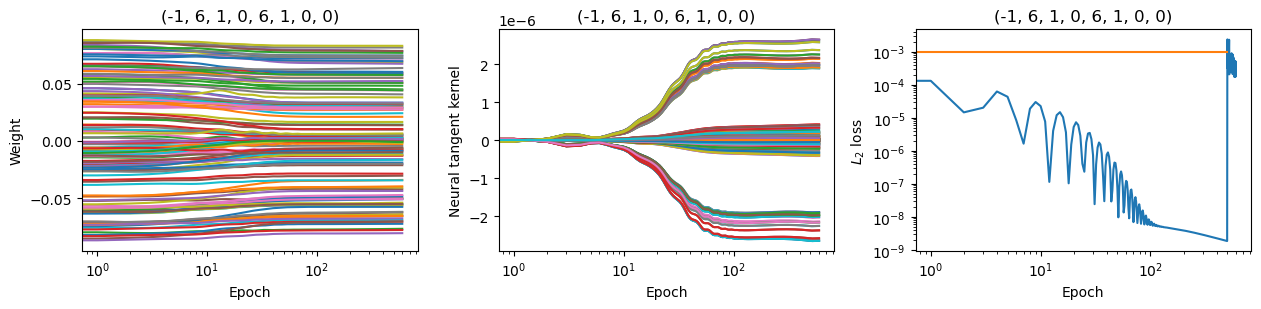

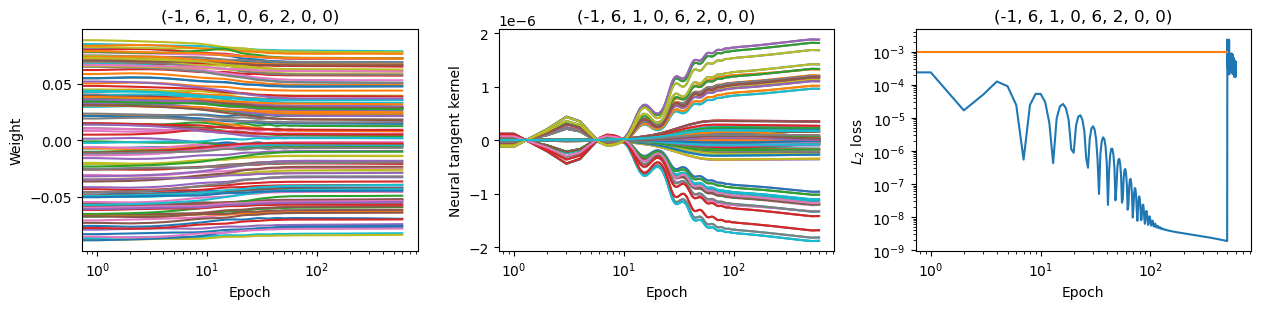

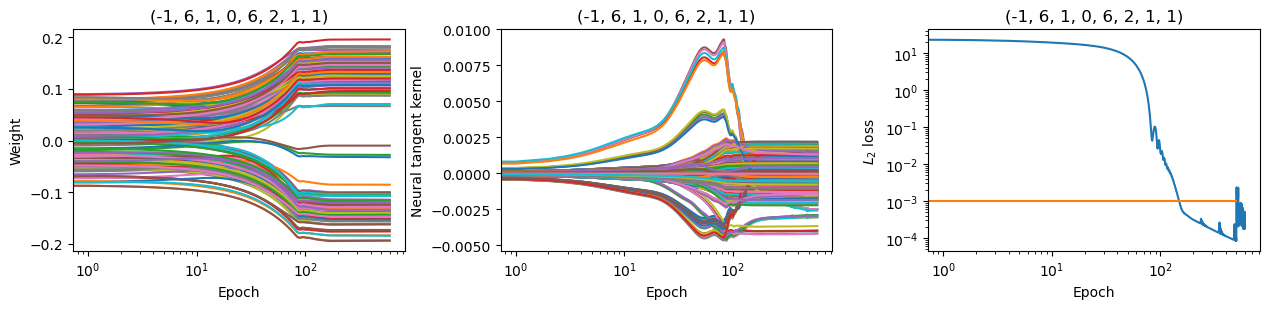

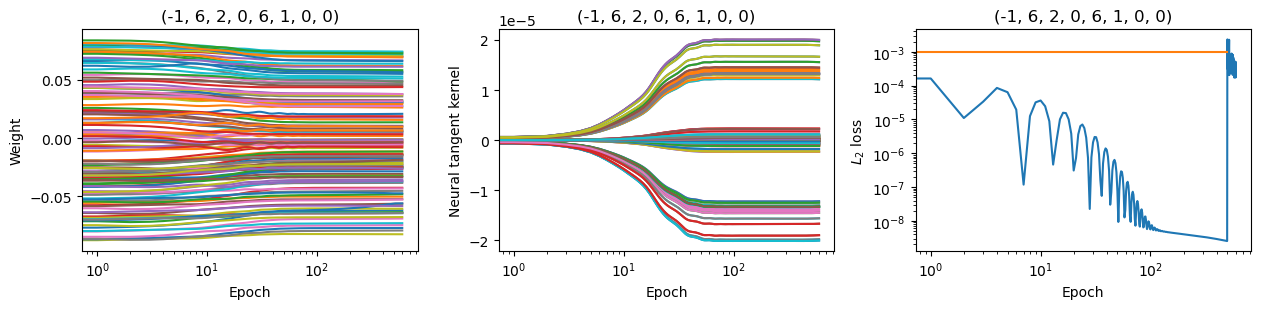

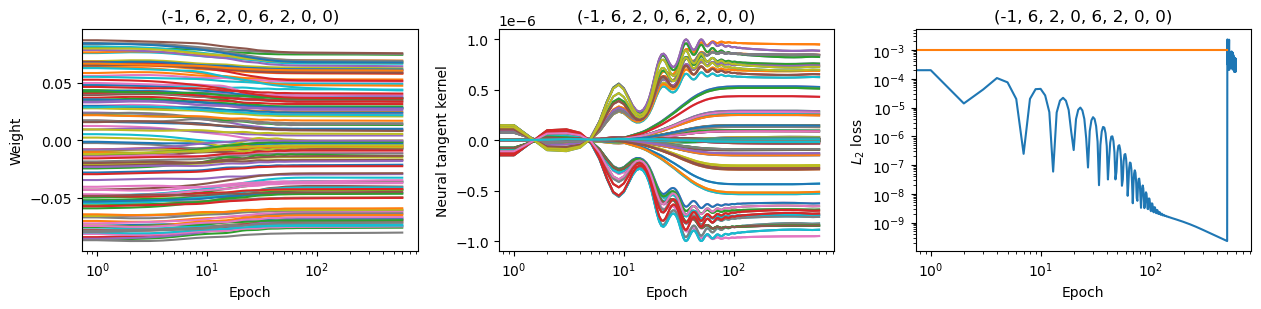

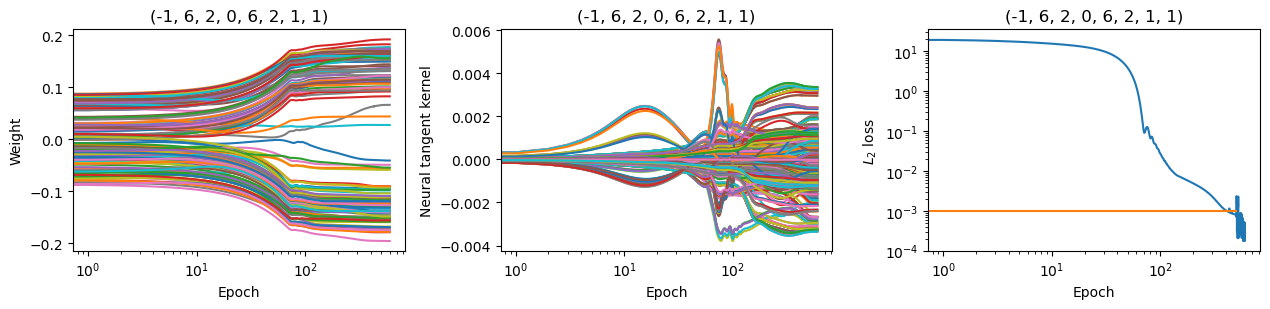

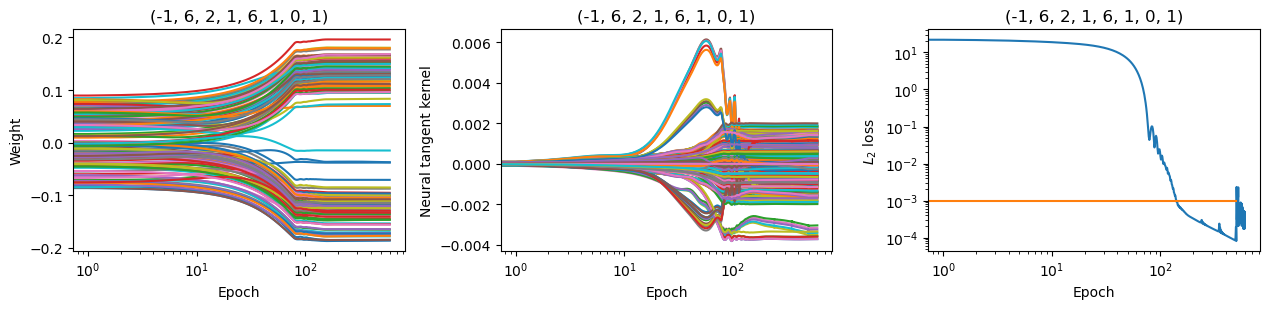

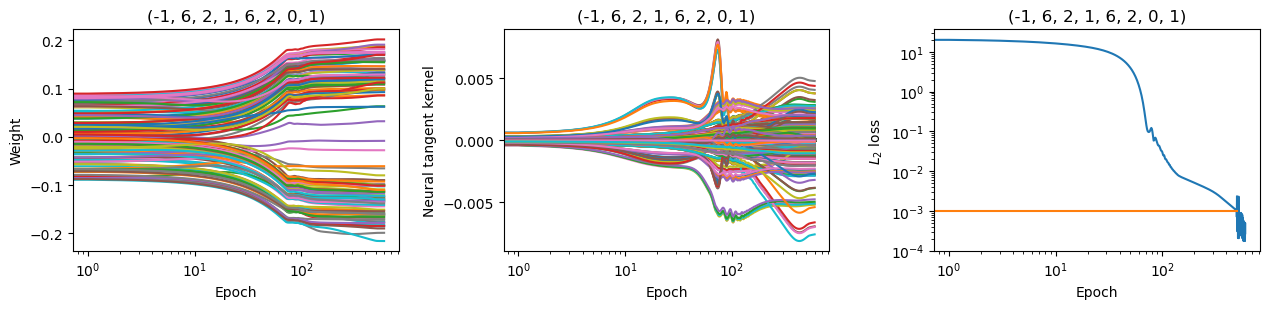

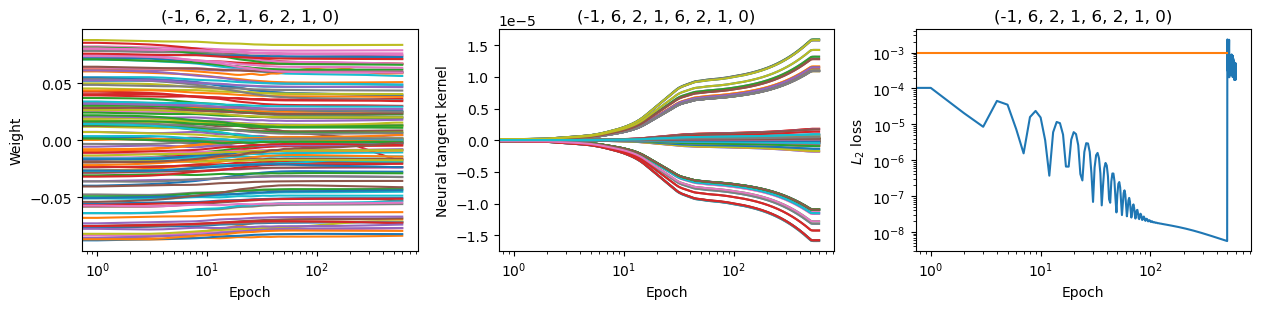

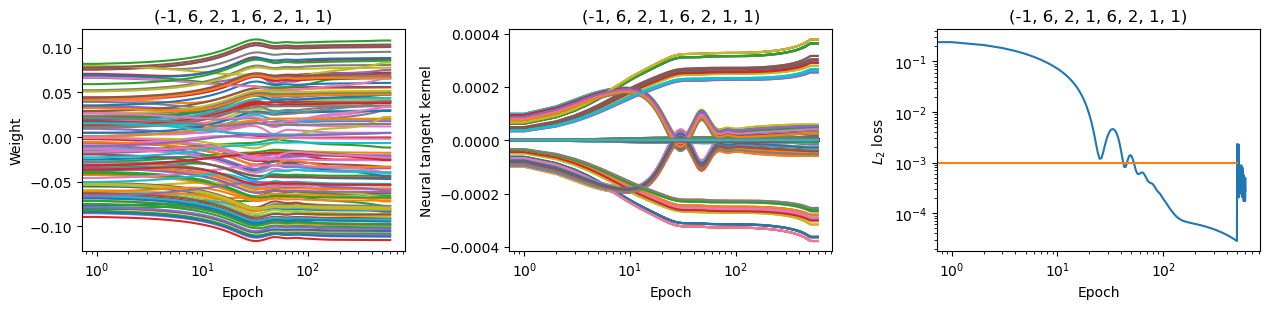

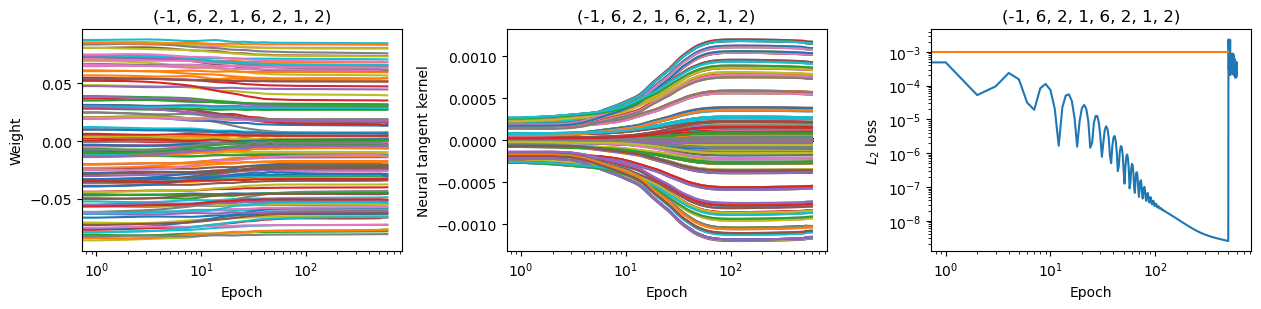

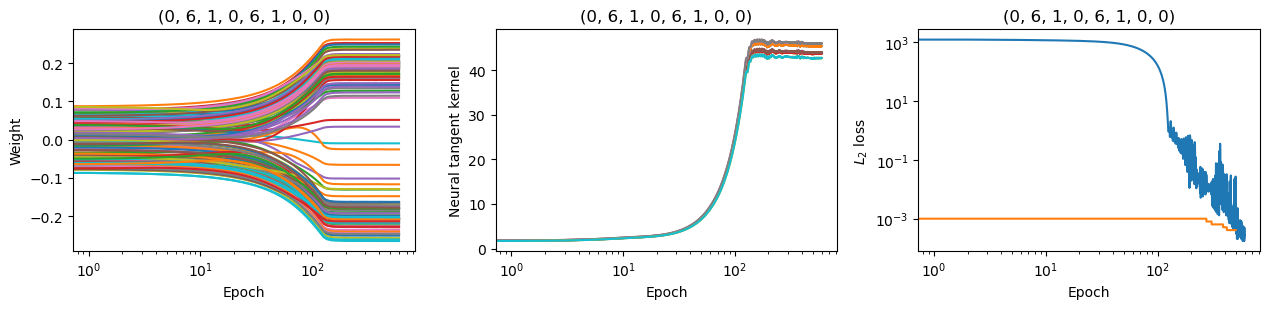

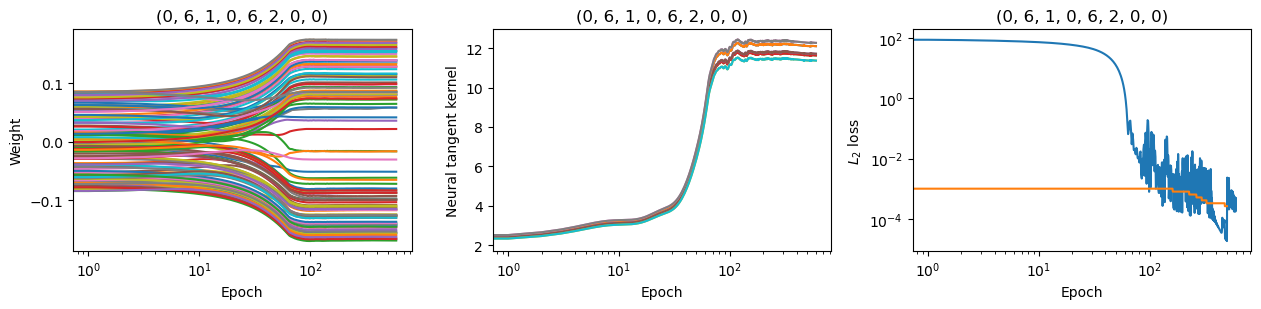

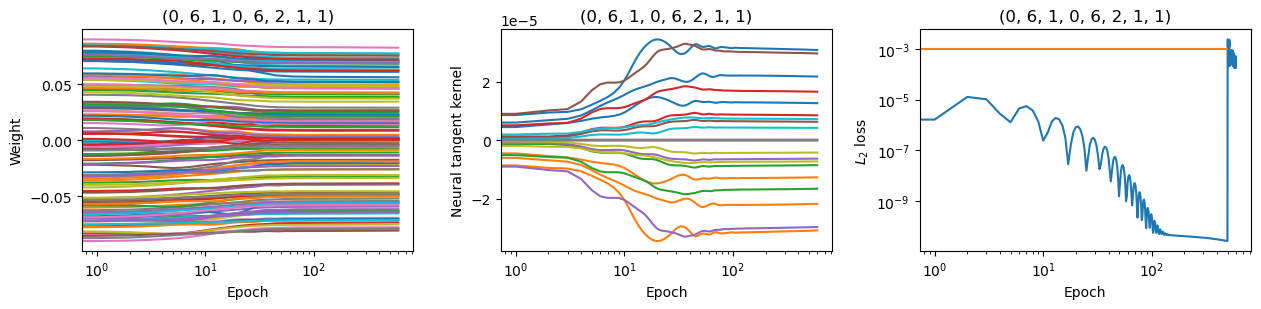

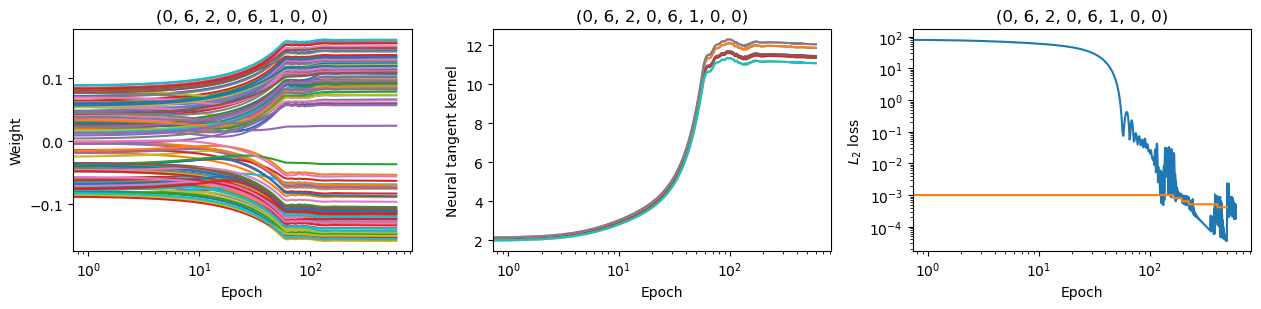

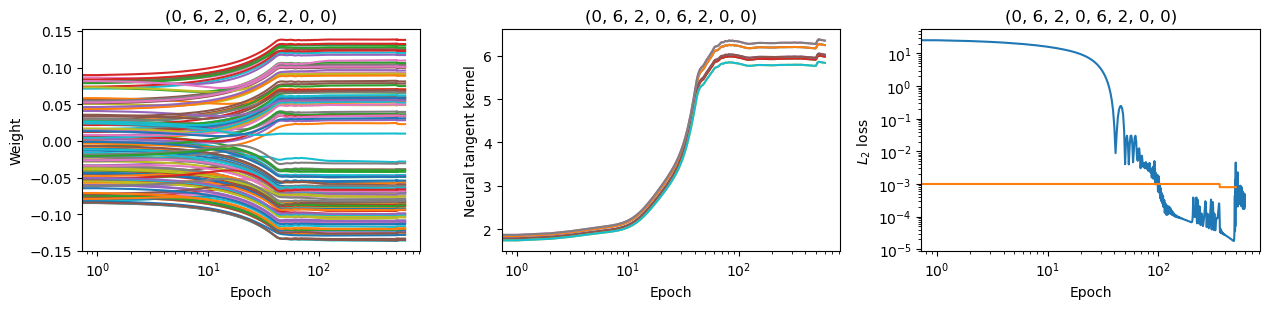

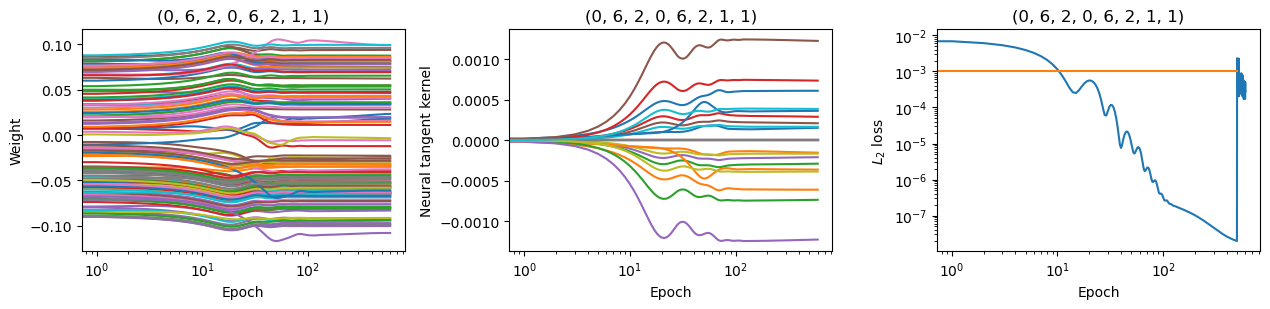

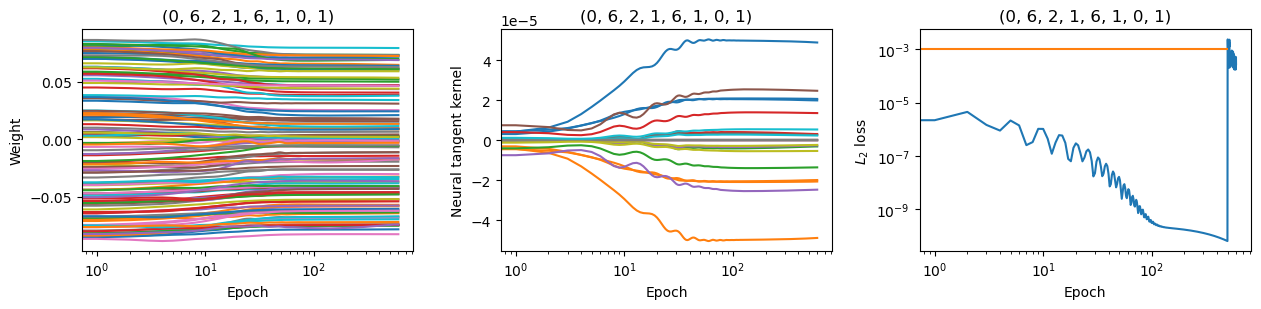

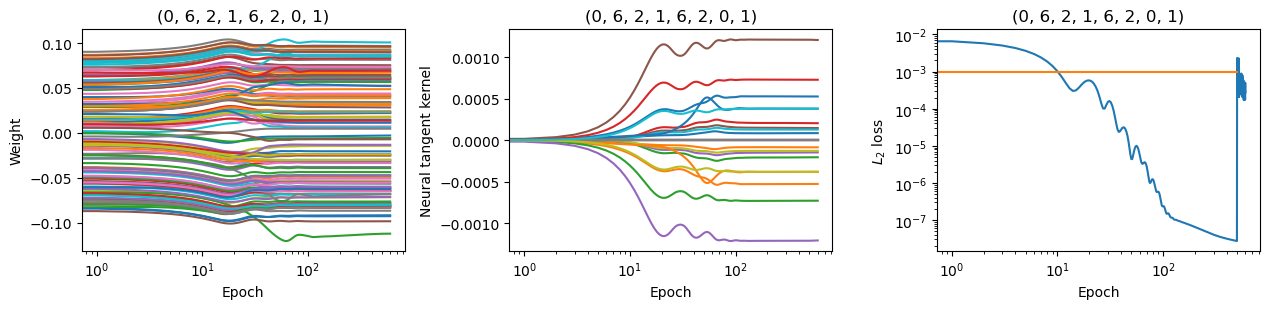

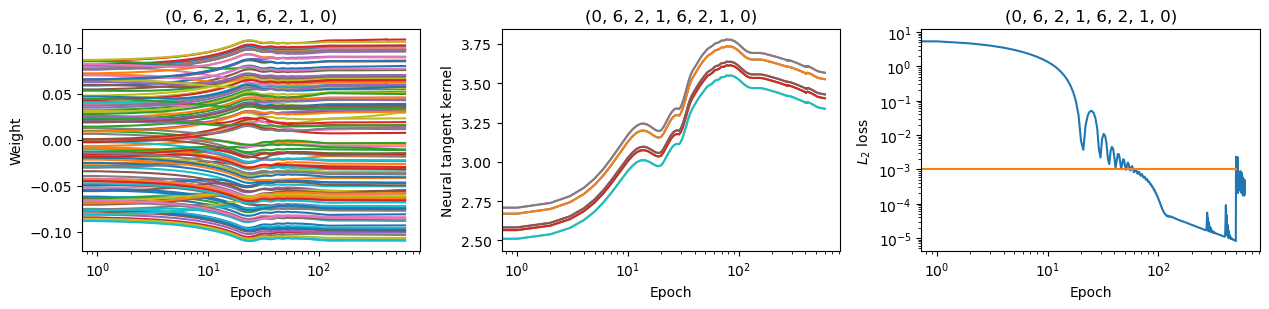

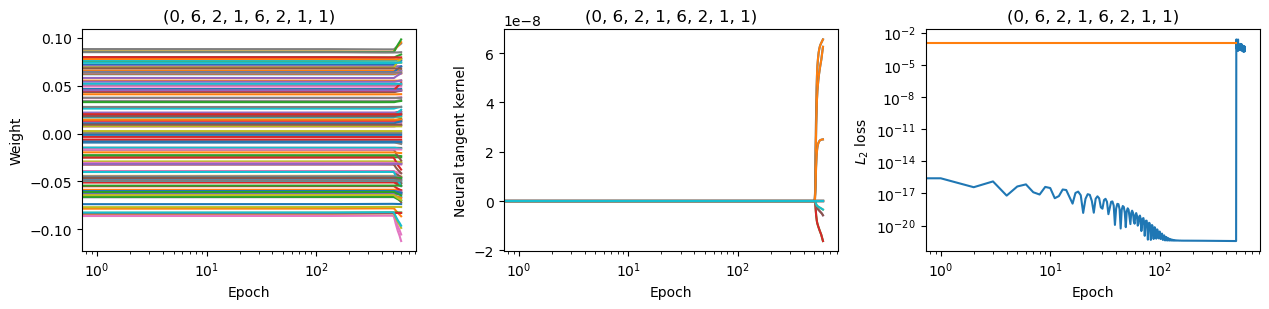

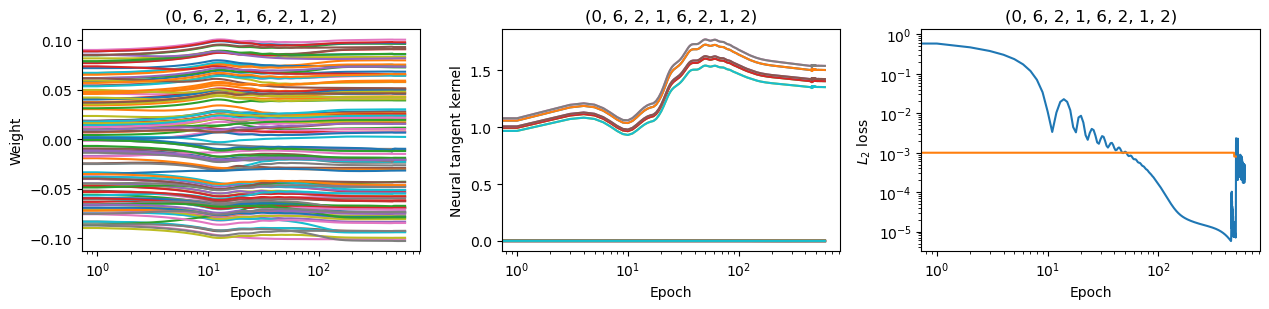

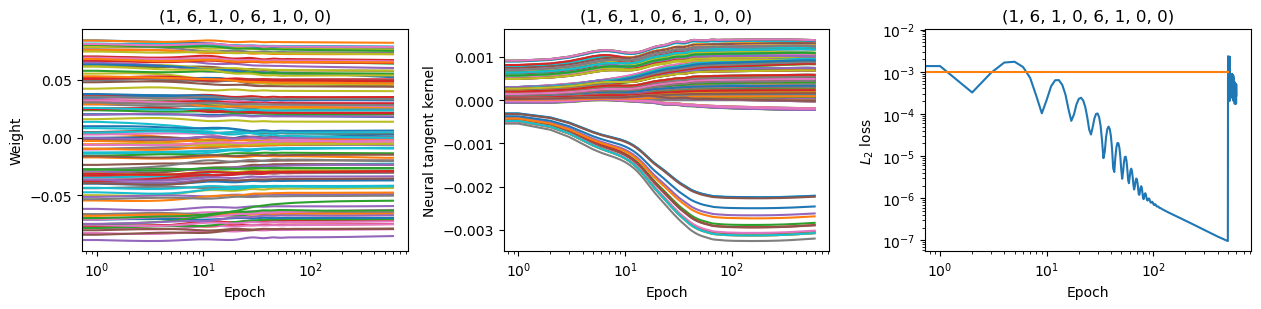

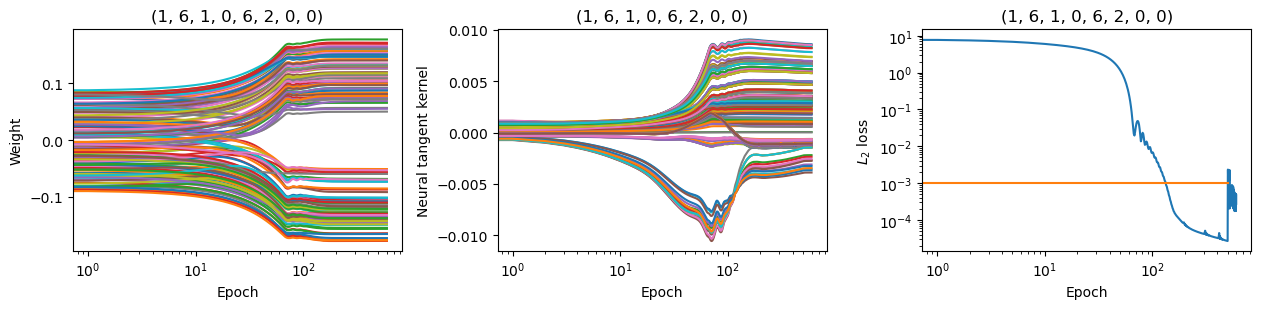

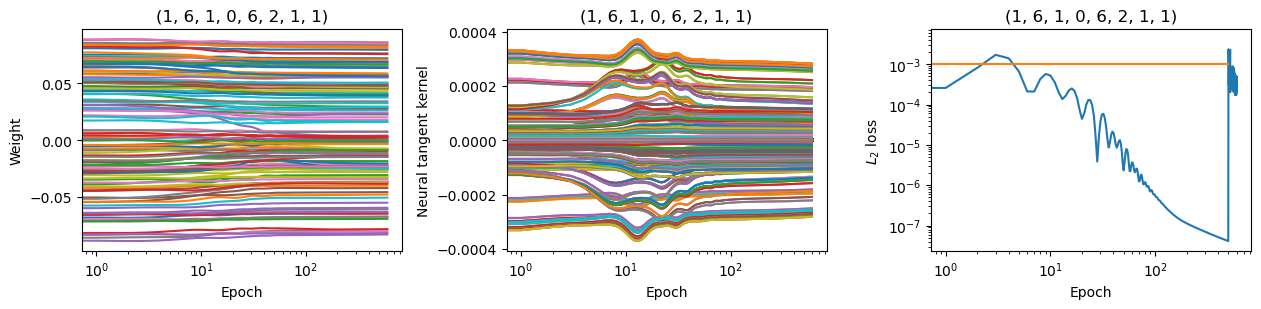

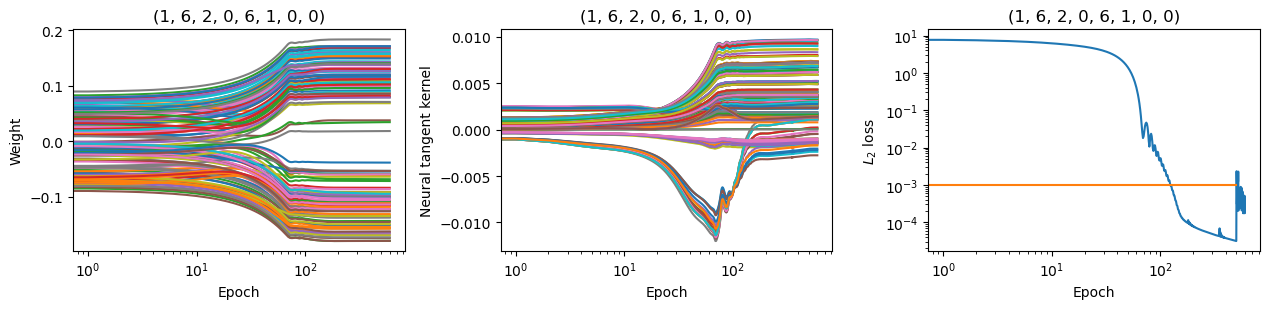

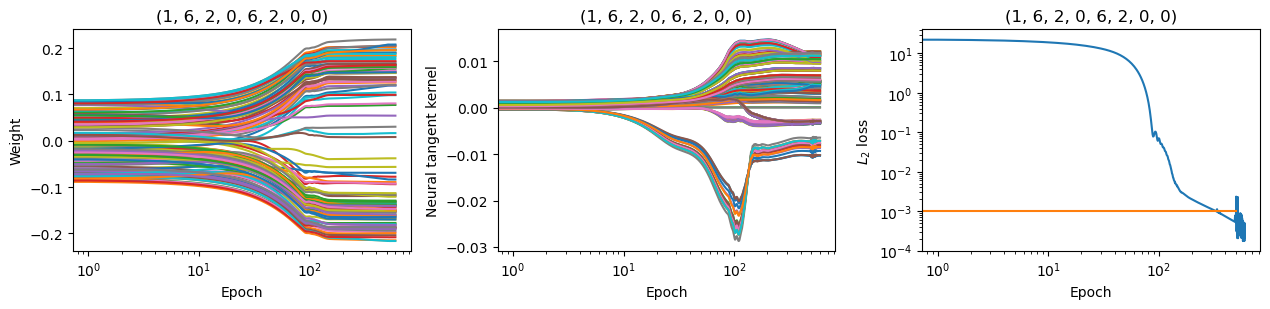

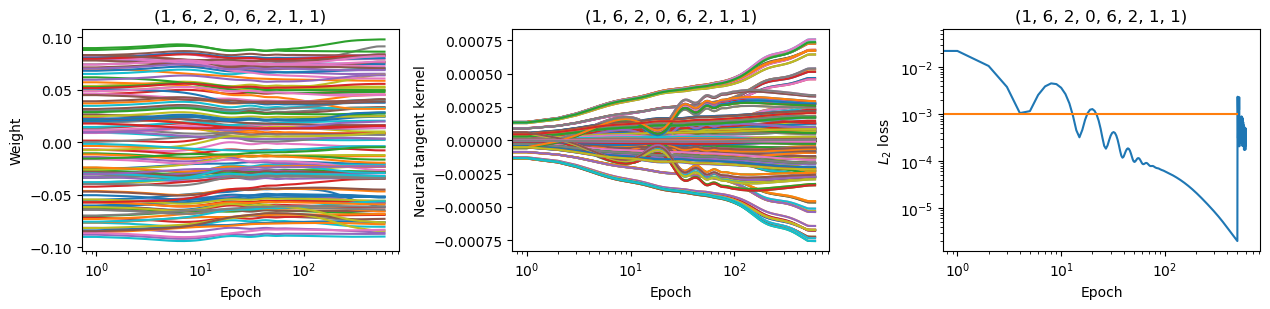

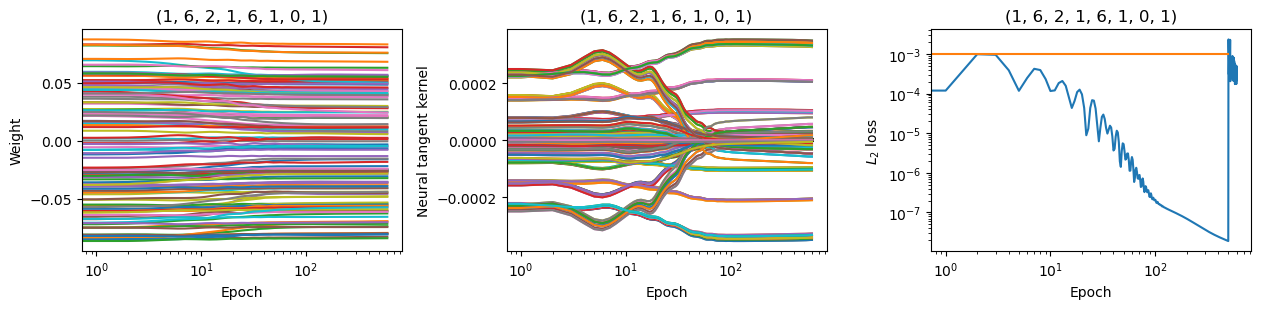

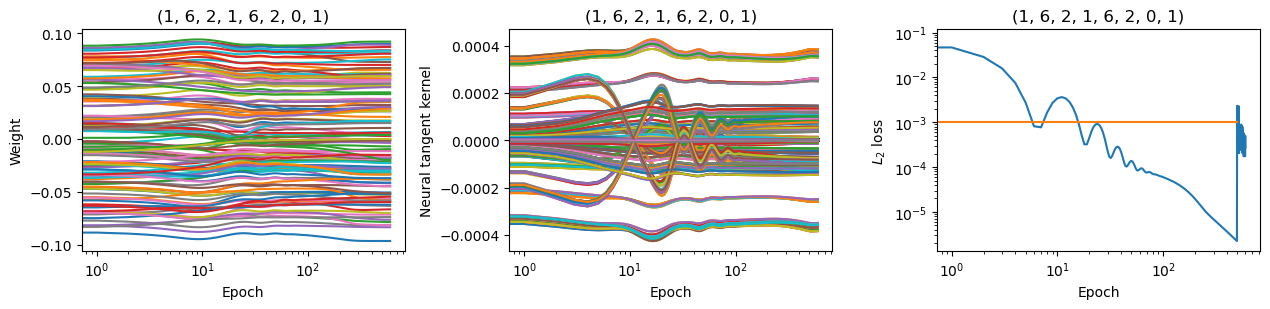

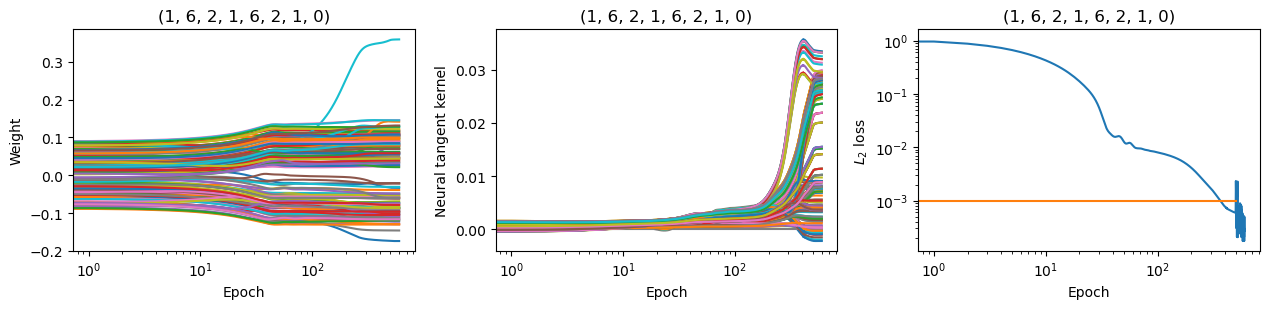

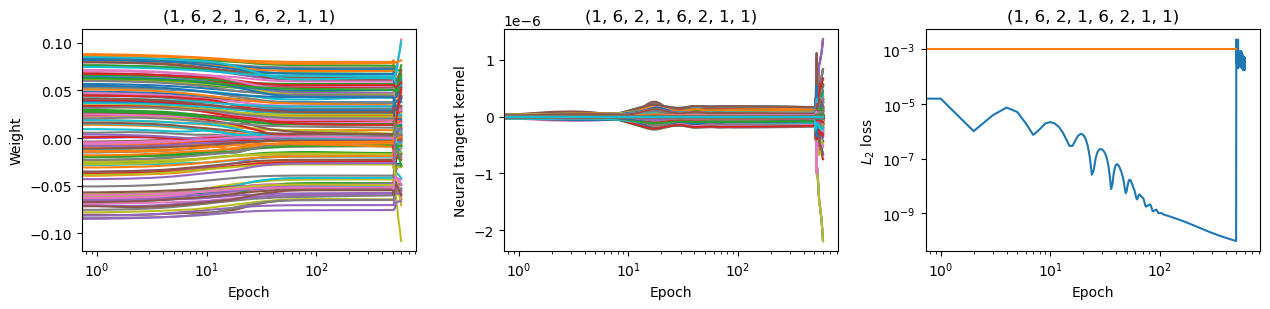

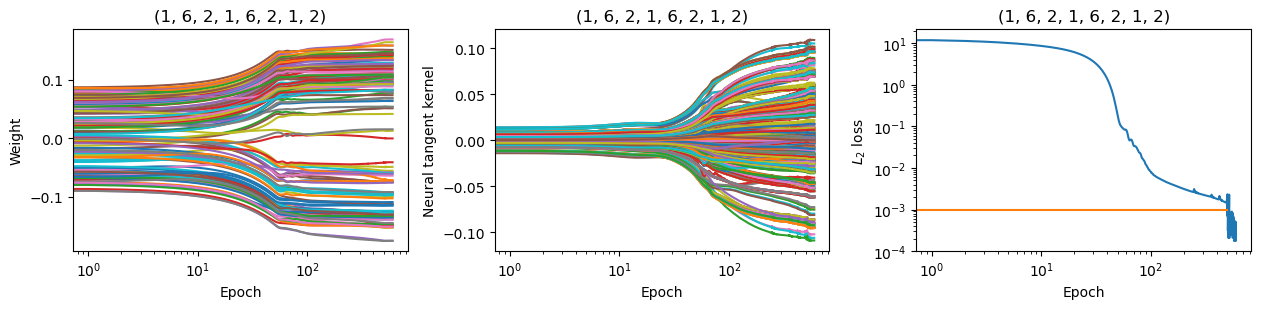

In [515]:
fs = plt.rcParams['figure.figsize']
for ik, k in enumerate(para):
    # if ik == 0:
    if True:
        kl = tuple(int(v) for v in k[1:-1].split(','))
        fig, axes = plt.subplots(ncols=3, figsize = (fs[0]*2, fs[1]/1.5))
        
        ax = axes[0]
        last_layer = torch.stack(para[k][5]).reshape(epoch+1, -1)
        for p in last_layer.T:
            y = p.detach().numpy()
            # y = np.abs(y-y[-1])
            # ax.plot(y/np.max(y))
            ax.plot(y)
        ax.set_title(k)
        ax.set_xscale('log')
        # ax.set_ylabel('$w$')
        # ax.set_ylabel(r'$\frac{w-w_{\mathrm{fin}}}{\mathrm{max}(w-w_{\mathrm{fin}})}$')
        ax.set_ylabel(r'Weight')
        ax.set_xlabel('Epoch')
    
        ax = axes[2]
        y = np.array(losses[k])
        ax.loglog(y)
        # ax.loglog(y/y[0])
        ax.loglog(learning_rates[k])
        ax.set_title(k)
        ax.set_ylabel('$L_2$ loss')
        # ax.set_ylabel('$L_2$ loss (normalized to 1 at epoch=0)')
        ax.set_xlabel('Epoch')
    
        # ax = axes[1]
        # kern = torch.stack(last_layer_kernel[kl])
        # for comp in range(kern.shape[1]):
        #     # y = torch.mean(kern[:, comp]-kern[-1, comp, :, :], dim = (1,2))
        #     # y_std = torch.std(kern[:, comp]-kern[-1, comp, :, :], dim = (1,2))
        #     # pl, = ax.plot(np.arange(len(y)), y)
        #     # ax.fill_between(np.arange(len(y)), y-y_std, y+y_std, alpha = 0.5, color = pl.get_color())
        #     for i in range(kern.shape[2]):
        #         for j in [0]: #range(kern[0].shape[1]):
        #             y = kern[:, comp, i, j]
        #             if j == 0:
        #                 pl, = ax.plot(y)
        #             else:
        #                 ax.plot(y, c = pl.get_color())
        # ax.set_ylabel('Neural tangent kernel')
        # ax.set_xlabel('Epoch')
        # ax.set_title(k)
                    
        # ax.set_xscale('log')
        fig.tight_layout()